In [9]:
import pandas as pd 
import numpy as np

data_path = "Ex2/Bangalore_House_Price_data/Bengaluru_House_Data.csv"
df = pd.read_csv(data_path)

In [11]:
varibles = []

for var in df.columns:
    varibles.append(var)
    print(df[var])

0        Super built-up  Area
1                  Plot  Area
2              Built-up  Area
3        Super built-up  Area
4        Super built-up  Area
                 ...         
13315          Built-up  Area
13316    Super built-up  Area
13317          Built-up  Area
13318    Super built-up  Area
13319    Super built-up  Area
Name: area_type, Length: 13320, dtype: object
0               19-Dec
1        Ready To Move
2        Ready To Move
3        Ready To Move
4        Ready To Move
             ...      
13315    Ready To Move
13316    Ready To Move
13317    Ready To Move
13318           18-Jun
13319    Ready To Move
Name: availability, Length: 13320, dtype: object
0        Electronic City Phase II
1                Chikka Tirupathi
2                     Uttarahalli
3              Lingadheeranahalli
4                        Kothanur
                   ...           
13315                  Whitefield
13316               Richards Town
13317       Raja Rajeshwari Nagar
13318           

In [ ]:
df.isnull().sum() 

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [14]:
df.isnull().mean()

area_type       0.000000
availability    0.000000
location        0.000075
size            0.001201
society         0.413063
total_sqft      0.000000
bath            0.005480
balcony         0.045721
price           0.000000
dtype: float64

In [18]:
df2 = df.drop('society', axis=1)

In [22]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

df3 = df2.dropna()
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [26]:
total_sqft_float = []
for str_val in df3['total_sqft']:
    try:
        total_sqft_float.append(float(str_val))
    except:
        try:
            temp = []
            temp = str_val.split('-')
            total_sqft_float.append((float(temp[0])+float(temp[-1]))/2)
        except:
            total_sqft_float.append(np.nan)

In [27]:
df4 = df3.reset_index(drop=True)

In [28]:
df5 = df4.join(pd.DataFrame({'total_sqft_float':total_sqft_float}))
df5.head() #Quan sát kết quả sau khi xử lí

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [29]:
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [34]:
df6 = df5.dropna()

In [36]:
size_int = []
for str_val in df6['size']:
    temp=[]
    temp = str_val.split(" ")
    try:
        size_int.append(int(temp[0]))
    except:
        size_int.append(np.nan)
        print("Noice = ",str_val)
        

In [37]:
df6 = df6.reset_index(drop=True)

In [38]:
df7 = df6.join(pd.DataFrame({'bhk':size_int}))
df7.shape

(13200, 10)

In [40]:
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 350)]
df8.shape

(12106, 10)

In [41]:
df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']
df8.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_728\622000310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000


In [ ]:
import matplotlib.pyplot as plt
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
plt.figure(figsize=(16,12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

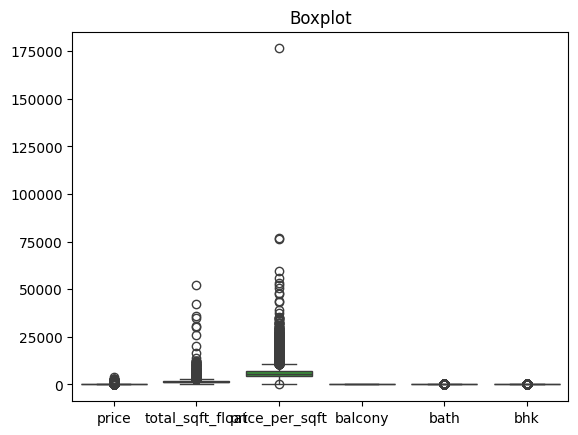

In [ ]:
import seaborn as sns

sns.boxplot(data=df8[vars])
plt.title('Boxplot')
plt.show()

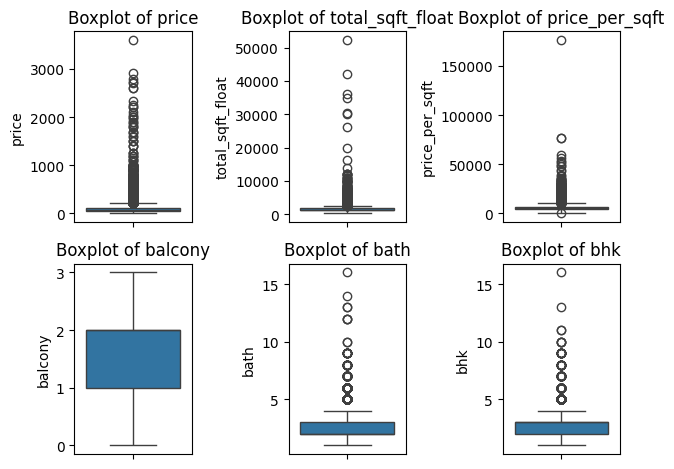

In [61]:
for i, col in enumerate(vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df8, y=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [70]:
df8.shape

(12106, 11)

In [73]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-st))&(subdf.price_per_sqft<=(m+st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index = True)
    return df_out

df9 = remove_pps_outliers(df8)
df9.shape

(8888, 11)

In [76]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk]={
            'mean':np.mean(bhk_df.price_per_sqft),
            'std':np.std(bhk_df.price_per_sqft),
            'count':bhk_df.shape[0]}
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')
df10 = remove_bhk_outliers(df9)
df10.shape

(7194, 11)

In [77]:
df11 = df10[df10.bath < df10.bhk+2]
df11.shape

(7120, 11)

In [78]:
df12 = df11.drop(['area_type', 'availability',"location","size","total_sqft"], axis =1)
df12.head()

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,3.0,2.0,150.0,1672.0,3,8971.291866
1,3.0,3.0,149.0,1750.0,3,8514.285714
2,3.0,2.0,150.0,1750.0,3,8571.428571
4,2.0,2.0,40.0,1250.0,2,3200.000000
5,2.0,2.0,83.0,1200.0,2,6916.666667


In [79]:
df12.to_csv("clean_data.csv", index=False)

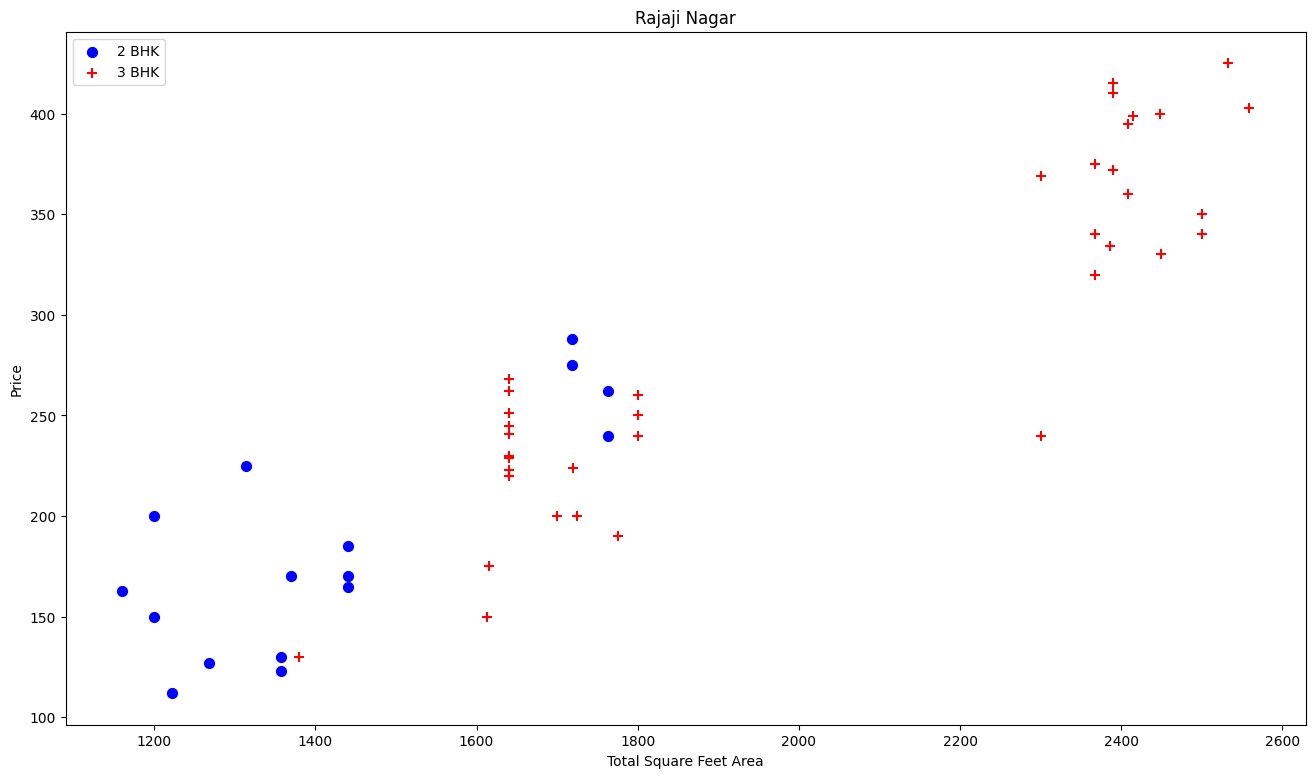

In [80]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.bhk==2)]
    bhk3 = df[(df.location==location) & (df.bhk==3)]
    plt.figure(figsize=(16,9))
    plt.scatter(bhk2.total_sqft_float, bhk2.price, color='Blue', label='2 BHK', s=50)
    plt.scatter(bhk3.total_sqft_float, bhk3.price, color='Red', label='3 BHK',s=50, marker="+")
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df9, "Rajaji Nagar")

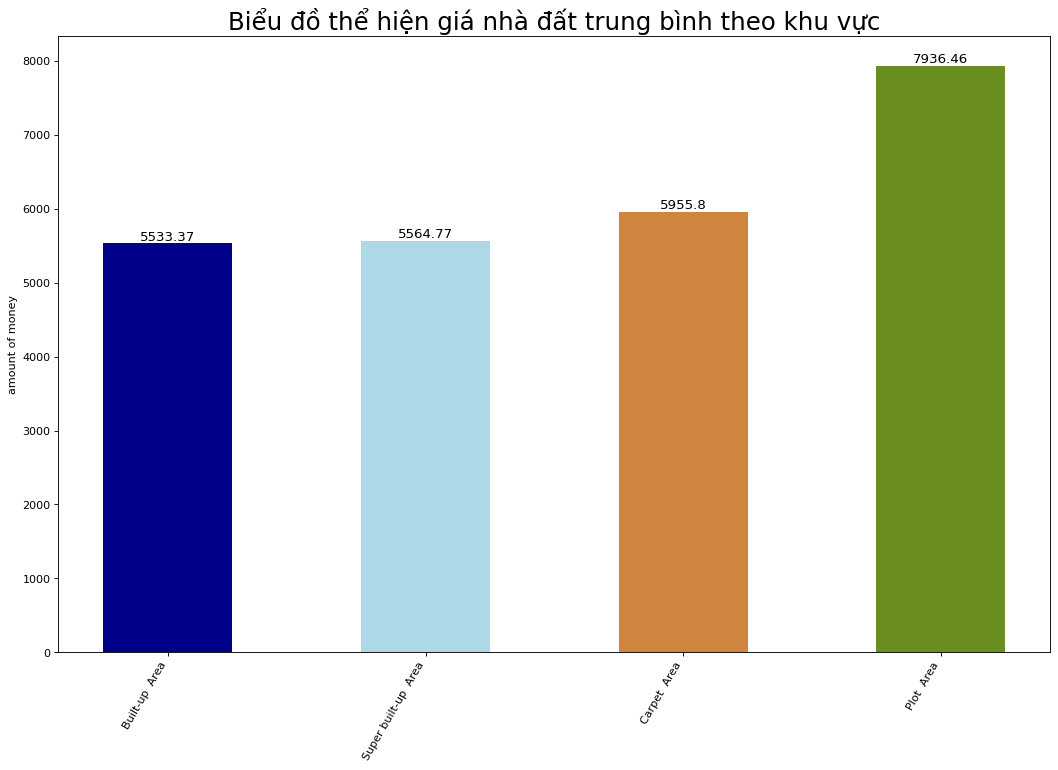

In [86]:
import random

df91 = df9.groupby('area_type')['price_per_sqft'].mean().reset_index(name='money')
df91 = df91.sort_values(by='money')
df91['money'] = df91['money'].round(2)
n = len(df91)
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100) 
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16, 10), dpi=80)
bars = plt.bar(df91['area_type'], df91['money'], color=c, width=0.5)

for i, val in enumerate(df91['money'].values):
    plt.text(i, val, float(val),  horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight': 500, 'size': 12})

ax = plt.gca()
ax.set_xticks(range(len(df91)))
ax.set_xticklabels(df91['area_type'], rotation=60, horizontalalignment='right')

plt.title("Biểu đồ thể hiện giá nhà đất trung bình theo khu vực", fontsize=22)
plt.ylabel('amount of money')

plt.show()